In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from textblob import TextBlob
from collections import Counter

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
data = {
    "Review": [
        "Food was delicious and delivery was fast",
        "Poor packaging and cold food",
        "Excellent customer service",
        "Delivery was very late and food was bad",
        "Reasonable price and tasty food",
        "Packaging was damaged",
        "Staff was very helpful",
        "Food quality was poor",
        "Amazing taste and quick delivery",
        "Customer service needs improvement",
        "The burger was fresh and tasty",
        "Food arrived cold and late",
        "Good quality food at reasonable price",
        "Terrible packaging experience",
        "Very satisfied with the service"
    ]
}

df = pd.DataFrame(data)

df.head()

,Review
0,Food was delicious and delivery was fast
1,Poor packaging and cold food
2,Excellent customer service
3,Delivery was very late and food was bad
4,Reasonable price and tasty food


In [ ]:
print("Total Reviews:", len(df))
df

Total Reviews: 15


,Review
0,Food was delicious and delivery was fast
1,Poor packaging and cold food
2,Excellent customer service
3,Delivery was very late and food was bad
4,Reasonable price and tasty food
5,Packaging was damaged
6,Staff was very helpful
7,Food quality was poor
8,Amazing taste and quick delivery
9,Customer service needs improvement


In [ ]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Review"] = df["Review"].apply(preprocess)

df.head()

,Review,Cleaned_Review
0,Food was delicious and delivery was fast,food delicious delivery fast
1,Poor packaging and cold food,poor packaging cold food
2,Excellent customer service,excellent customer service
3,Delivery was very late and food was bad,delivery late food bad
4,Reasonable price and tasty food,reasonable price tasty food


In [ ]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Review"].apply(get_sentiment)

df.head()

,Review,Cleaned_Review,Sentiment
0,Food was delicious and delivery was fast,food delicious delivery fast,Positive
1,Poor packaging and cold food,poor packaging cold food,Negative
2,Excellent customer service,excellent customer service,Positive
3,Delivery was very late and food was bad,delivery late food bad,Negative
4,Reasonable price and tasty food,reasonable price tasty food,Positive


In [ ]:
df[["Review","Sentiment"]]

,Review,Sentiment
0,Food was delicious and delivery was fast,Positive
1,Poor packaging and cold food,Negative
2,Excellent customer service,Positive
3,Delivery was very late and food was bad,Negative
4,Reasonable price and tasty food,Positive
5,Packaging was damaged,Neutral
6,Staff was very helpful,Neutral
7,Food quality was poor,Negative
8,Amazing taste and quick delivery,Positive
9,Customer service needs improvement,Neutral


In [ ]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    7
Negative    5
Neutral     3
Name: count, dtype: int64


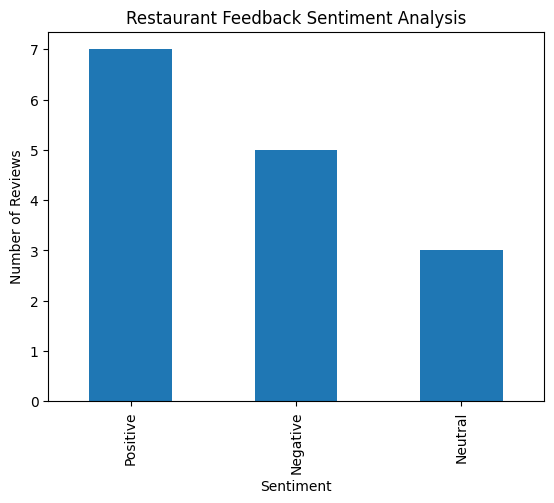

In [ ]:
sentiment_counts.plot(kind="bar")

plt.title("Restaurant Feedback Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
negative_reviews = df[df["Sentiment"]=="Negative"]

negative_reviews

,Review,Cleaned_Review,Sentiment
1,Poor packaging and cold food,poor packaging cold food,Negative
3,Delivery was very late and food was bad,delivery late food bad,Negative
7,Food quality was poor,food quality poor,Negative
11,Food arrived cold and late,food arrived cold late,Negative
13,Terrible packaging experience,terrible packaging experience,Negative


In [ ]:
all_words = " ".join(negative_reviews["Cleaned_Review"])

words = all_words.split()

word_freq = Counter(words)

print(word_freq.most_common(10))

[('food', 4), ('poor', 2), ('packaging', 2), ('cold', 2), ('late', 2), ('delivery', 1), ('bad', 1), ('quality', 1), ('arrived', 1), ('terrible', 1)]


In [ ]:
print("RESTAURANT FEEDBACK ANALYSIS REPORT")
print("----------------------------------")

print("\nTotal Reviews:",len(df))

print("\nSentiment Distribution:")

print(df["Sentiment"].value_counts())

print("\nTop Issues:")

print(word_freq.most_common(5))

RESTAURANT FEEDBACK ANALYSIS REPORT
----------------------------------

Total Reviews: 15

Sentiment Distribution:
Sentiment
Positive    7
Negative    5
Neutral     3
Name: count, dtype: int64

Top Issues:
[('food', 4), ('poor', 2), ('packaging', 2), ('cold', 2), ('late', 2)]


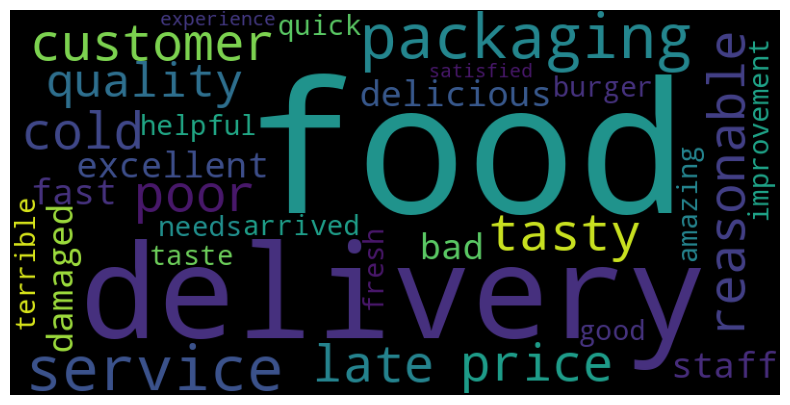

In [12]:
from wordcloud import WordCloud

text = " ".join(df["Cleaned_Review"])

wordcloud = WordCloud(width=800,height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()